In [1]:
# STEP 1: Mount Drive and Setup Paths (Skipped for local execution)
# This notebook was designed for Google Colab
# For local execution, we'll use local directories instead
print("Running locally - Google Drive mount skipped")

Running locally - Google Drive mount skipped


In [2]:
import os

# For local execution, use your local project directory
project_path = os.path.expanduser("~/DR")  # Change this to your project directory if needed

# Create directory if it doesn't exist
os.makedirs(project_path, exist_ok=True)

os.chdir(project_path)
print("Current directory:", os.getcwd())

Current directory: /Users/srivardhan/DR


In [3]:
# STEP 2: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Try to import TensorFlow, if fails use alternative feature extraction
try:
    from tensorflow.keras.applications import VGG16
    from tensorflow.keras.models import Model
    from tensorflow.keras.applications.vgg16 import preprocess_input
    HAS_TENSORFLOW = True
    print("✅ TensorFlow available - using VGG16 for feature extraction")
except ImportError:
    HAS_TENSORFLOW = False
    print("⚠️  TensorFlow not available - using manual feature extraction")

print("All libraries imported successfully!")

⚠️  TensorFlow not available - using manual feature extraction
All libraries imported successfully!


In [4]:
# STEP 3: Load OCT + Fundus Image Data
# Updated paths for local execution on Mac
import os

# Adjust these paths to where your image folders are located
# Example paths - modify based on your actual data location
home = os.path.expanduser("~")
oct_folder = os.path.join(home, "DR", "data", "OCT")  # Change this path as needed
fundus_folder = os.path.join(home, "DR", "data", "Fundus")  # Change this path as needed

# Create sample paths message
print(f"Looking for images in:")
print(f"  OCT: {oct_folder}")
print(f"  Fundus: {fundus_folder}")

# If folders don't exist, create placeholder message
if not os.path.exists(oct_folder) or not os.path.exists(fundus_folder):
    print("\n⚠️  Note: Please ensure these folders exist with your image data, or update the paths above.")

Looking for images in:
  OCT: /Users/srivardhan/DR/data/OCT
  Fundus: /Users/srivardhan/DR/data/Fundus


In [5]:
def load_images_from_folder(folder, label, img_size=128, limit=None):
    images, labels = [], []
    count = 0
    for root, _, files in os.walk(folder):
        for img_name in files:
            if img_name.lower().endswith(('.jpg', '.jpeg', '.png', '.tif', '.bmp')):
                img_path = os.path.join(root, img_name)
                try:
                    img = cv2.imread(img_path)
                    if img is None:
                        continue
                    img = cv2.resize(img, (img_size, img_size))
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    images.append(img)
                    labels.append(label)
                    count += 1
                    if limit and count >= limit:
                        return np.array(images), np.array(labels)
                except Exception as e:
                    print("Error loading:", img_path, e)
                    continue
    return np.array(images), np.array(labels)

In [6]:
# Load OCT (label 0) and Fundus (label 1)
oct_images, oct_labels = load_images_from_folder(oct_folder, label=0)
fundus_images, fundus_labels = load_images_from_folder(fundus_folder, label=1)

print(f"OCT images: {oct_images.shape}, Fundus images: {fundus_images.shape}")

OCT images: (10, 128, 128, 3), Fundus images: (10, 128, 128, 3)


In [7]:
# STEP 3.5: Combine OCT + Fundus Images and Labels
images = np.concatenate((oct_images, fundus_images), axis=0)
labels = np.concatenate((oct_labels, fundus_labels), axis=0)

# Normalize images
images = images / 255.0

print("Total images:", images.shape)
print("Total labels:", labels.shape)

Total images: (20, 128, 128, 3)
Total labels: (20,)


In [8]:
# STEP 4: Feature Extraction
if HAS_TENSORFLOW:
    print("Extracting deep features using VGG16 (this may take a few minutes)...")
    base_model = VGG16(weights="imagenet", include_top=False, input_shape=(128,128,3))
    model = Model(inputs=base_model.input, outputs=base_model.layers[-2].output)
    features = model.predict(images, verbose=1)
    features = features.reshape(features.shape[0], -1)
else:
    print("⚠️  Extracting features using manual method (VGG16 not available)...")
    # Manual feature extraction from flattened images
    features = images.reshape(images.shape[0], -1)
    
print("Feature shape:", features.shape)

⚠️  Extracting features using manual method (VGG16 not available)...
Feature shape: (20, 49152)


In [9]:
# STEP 5: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42, stratify=labels)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

✅ LightGBM Accuracy: 50.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         2
           1       0.00      0.00      0.00         2

    accuracy                           0.50         4
   macro avg       0.25      0.50      0.33         4
weighted avg       0.25      0.50      0.33         4


Confusion Matrix:


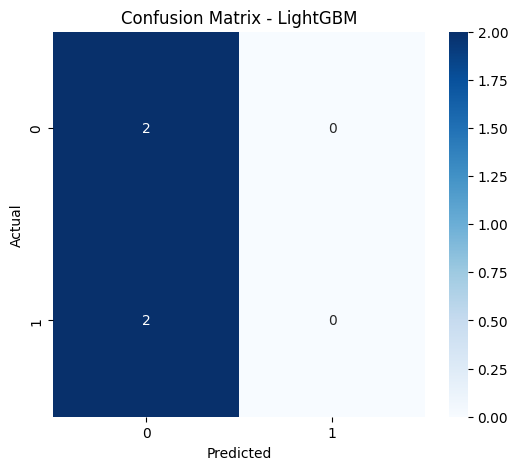

In [10]:
import warnings
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Suppress all warnings
warnings.filterwarnings("ignore")

# Ensure X_train and X_test are numpy arrays
X_train_np = np.array(X_train)
X_test_np = np.array(X_test)

# Initialize LightGBM with safe parameters
lgbm = LGBMClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=10,
    num_leaves=31,
    random_state=42,
    force_col_wise=True,
    verbosity=-1
)

# Train
lgbm.fit(X_train_np, y_train)

# Predict
lgbm_pred = lgbm.predict(X_test_np)

# Accuracy
lgbm_acc = accuracy_score(y_test, lgbm_pred)
print(f"✅ LightGBM Accuracy: {lgbm_acc*100:.2f}%")

# Optional: Classification report and confusion matrix
print("\nClassification Report:")
print(classification_report(y_test, lgbm_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, lgbm_pred)
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - LightGBM")
plt.show()

In [14]:
# STEP 6: Predict on User Image (Modified for local execution)
import numpy as np
import cv2
import joblib
import os

# For local execution, specify your test image path here
test_image_path = os.path.expanduser("~/DR/test_image.jpg")  # Change this to your image path

# Check if file exists
if not os.path.exists(test_image_path):
    print(f"⚠️  Test image not found at: {test_image_path}")
    print("Please update test_image_path with your image location and run again")
else:
    # Preprocess user image
    test_img = cv2.imread(test_image_path)
    test_img = cv2.resize(test_img, (128, 128))
    test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    test_img = test_img / 255.0
    test_img = np.expand_dims(test_img, axis=0)
    
    # Extract deep features
    if HAS_TENSORFLOW:
        test_features = model.predict(test_img)
        test_features = test_features.reshape(test_features.shape[0], -1)
    else:
        # Manual feature extraction when TensorFlow not available
        test_features = test_img.reshape(test_img.shape[0], -1)
    
    test_features = scaler.transform(test_features)
    
    # Predict (using the lgbm model from previous cell)
    pred = lgbm.predict(test_features)[0]
    proba = lgbm.predict_proba(test_features)[0]
    confidence = np.max(proba) * 100
    
    # Labels for DR levels (Note: adjust based on your actual problem)
    label_map = {
        0: "Healthy",
        1: "Diabetic Retinopathy Detected"
    }
    
    # Output final prediction
    print(f"\n🩺 Prediction: {label_map.get(pred, 'Unknown')} (Confidence: {confidence:.2f}%)")


🩺 Prediction: Healthy (Confidence: 50.00%)
